## Data Exploration

Key Hypothesis: Variability and intensity of digital exposure patterns are more strongly associated with depressive symptom severity than total daily screen time alone among emerging adults.

In [ ]:
#!pip install kagglehub

In [12]:
import kagglehub
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
path = kagglehub.dataset_download("souvikahmed071/social-media-and-mental-health")

print("Dataset downloaded to:", path)

print("Files inside dataset folder:")
print(os.listdir(path))


100%|██████████| 10.7k/10.7k [00:00<00:00, 5.67MB/s]

Extracting files...
Dataset downloaded to: /Users/nodokakushioka/.cache/kagglehub/datasets/souvikahmed071/social-media-and-mental-health/versions/15
Files inside dataset folder:
['smmh.csv']


In [5]:
file_name = "smmh.csv"
data = pd.read_csv(os.path.join(path, file_name))

display(data.head())
print(data.columns)

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


Index(['Timestamp', '1. What is your age?', '2. Gender',
       '3. Relationship Status', '4. Occupation Status',
       '5. What type of organizations are you affiliated with?',
       '6. Do you use social media?',
       '7. What social media platforms do you commonly use?',
       '8. What is the average time you spend on social media every day?',
       '9. How often do you find yourself using Social media without a specific purpose?',
       '10. How often do you get distracted by Social media when you are busy doing something?',
       '11. Do you feel restless if you haven't used Social media in a while?',
       '12. On a scale of 1 to 5, how easily distracted are you?',
       '13. On a scale of 1 to 5, how much are you bothered by worries?',
       '14. Do you find it difficult to concentrate on things?',
       '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
       '16. Following the previous question, 

In [6]:
data["Depression_Score"] = (
    data["18. How often do you feel depressed or down?"] +
    data["19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?"] +
    data["20. On a scale of 1 to 5, how often do you face issues regarding sleep?"]
)

In [7]:
time_map = {
    "Less than an hour": 0.5,
    "Between 1 and 2 hours": 1.5,
    "Between 2 and 3 hours": 2.5,
    "Between 3 and 4 hours": 3.5,
    "Between 4 and 5 hours": 4.5,
    "More than 5 hours": 6
}

data["SM_Hours_Numeric"] = data["8. What is the average time you spend on social media every day?"].map(time_map)


In [21]:
data["Exposure_Pattern_Score"] = (
    data["9. How often do you find yourself using Social media without a specific purpose?"] +
    data["11. Do you feel restless if you haven't used Social media in a while?"] +
    data["15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?"] +
    data["17. How often do you look to seek validation from features of social media?"]
)

In [22]:
corr_screen = data["SM_Hours_Numeric"].corr(data["Depression_Score"])
print(corr_screen)

0.2569937673594171


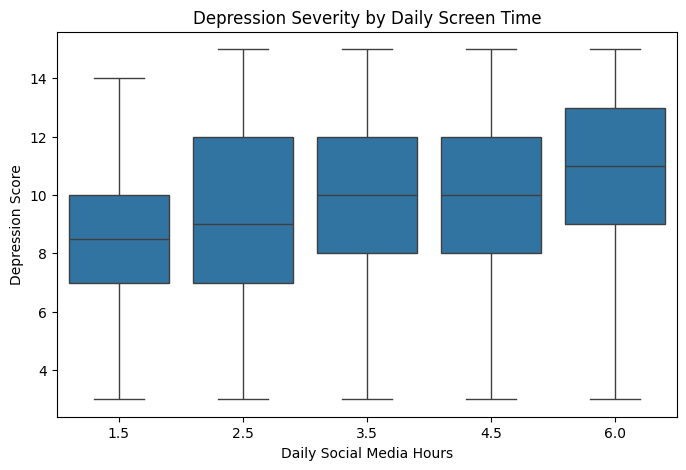

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="SM_Hours_Numeric",
    y="Depression_Score",
    data=data,
    showfliers=False
)

plt.title("Depression Severity by Daily Screen Time")
plt.xlabel("Daily Social Media Hours")
plt.ylabel("Depression Score")
plt.show()


In [24]:
corr_pattern = data["Exposure_Pattern_Score"].corr(data["Depression_Score"])
print(corr_pattern)


0.5462875889322266


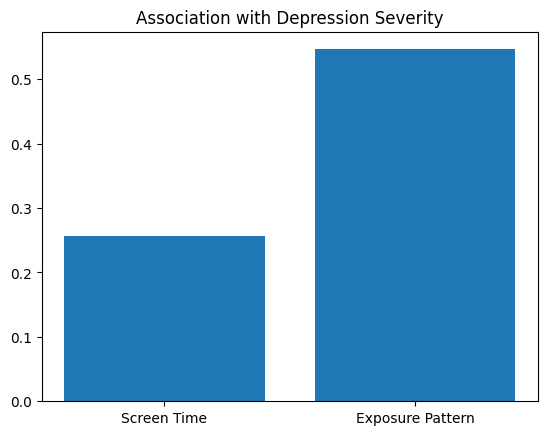

In [25]:
plt.bar(
    ["Screen Time", "Exposure Pattern"],
    [corr_screen, corr_pattern]
)
plt.title("Association with Depression Severity")
plt.show()

In [26]:
data["High_Pattern"] = data["Exposure_Pattern_Score"] > data["Exposure_Pattern_Score"].median()
data["High_Screen"] = data["SM_Hours_Numeric"] > data["SM_Hours_Numeric"].median()


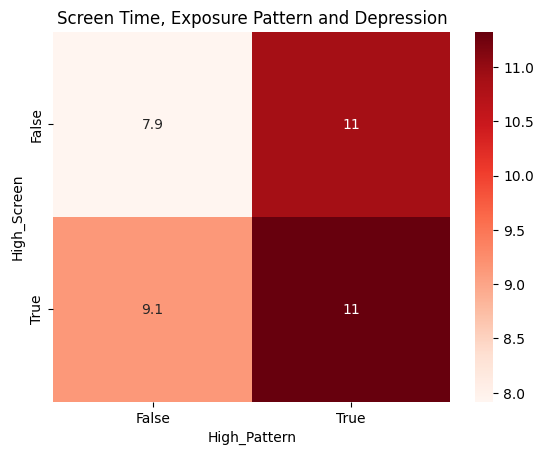

In [30]:
pivot = data.pivot_table(
    values="Depression_Score",
    index="High_Screen",
    columns="High_Pattern"
)

sns.heatmap(pivot, annot=True, cmap="Reds")
plt.title("Screen Time, Exposure Pattern and Depression")
plt.show()
